## Code for the "Morpheme Structure Phonotactics" paper

### Getting the data

In [1]:
import pandas as pd
import numpy as np

# taken from https://github.com/gouskova/transcribers
from transcriber_russ import transcription_wrapper as translit

In [2]:
#reads the experimental results of Becker and Gouskova
init_results_df = pd.read_csv('experiment_results copy.tsv', sep='\t')

#filters out the fillers (position = undefined means that there is no alternating vowel)
init_results_df = init_results_df[init_results_df['position'] != 'undefined']
init_results_df.count()

cluster            5516
monosyllablic      5516
order              5516
position           5516
prefix             2758
frame              5516
vowel              5516
subtype            5516
type               5516
C                  5516
time               5516
trialnumber        5516
userCode           5516
nom.rating         5516
accept.faithful    5516
accept.deletion    5516
dtype: int64

In [3]:
# create the pseudoform from the results
def create_form(row):
	pfx = row['prefix']
	cluster = row['cluster']
	position = row['position']
	prefix = row['prefix']
	vowel = row['vowel']
	core = ''
	if pd.isna(prefix):
		pfx = ''
	if position == '0':
		core = cluster[0] + vowel + cluster[1]
	elif position == '1':
		core = cluster[0] + vowel + cluster[1:]
	elif position == '2':
		core = cluster[:2] + vowel + cluster[2]
	else:
		return cluster
	return pfx + core
# create the type of the pseudoform from the results
def create_type(row):
	cluster = row['type']
	position = row['position']
	prefix = row['prefix']
	vowel = row['vowel']
	true_type = ''
	if not pd.isna(prefix):
		true_type += 'CV'
	if position == '0':
		true_type += cluster[0] + vowel + cluster[1]
	elif position == '1':
		true_type += cluster[0] + vowel + cluster[1:]
	elif position == '2':
		true_type += cluster[:2] + vowel + cluster[2]
	else:
		return 'Filler'
	return true_type
# create the subtype of the pseudoform from the results
def create_subtype(row):
	cluster = row['subtype']
	position = row['position']
	prefix = row['prefix']
	vowel = row['vowel']
	true_type = ''
	if not pd.isna(prefix):
		true_type += 'CV'
	if position == '0':
		true_type += cluster[0] + vowel + cluster[1]
	elif position == '1':
		true_type += cluster[0] + vowel + cluster[1:]
	elif position == '2':
		true_type += cluster[:2] + vowel + cluster[2]
	else:
		return 'Filler'
	return true_type


In [4]:
#add the pseudoform and the syllabic type to the results dataframe

init_results_df['pseudoform'] = init_results_df.apply(create_form, axis=1)
init_results_df['true_type'] = init_results_df.apply(create_type, axis=1)
init_results_df['true_subtype'] = init_results_df.apply(create_subtype, axis=1)
init_df = init_results_df.copy()
init_df['translit'] = init_df['pseudoform'].apply(lambda x: translit(x, UCLAPL="yes"))
init_df.head()

,cluster,monosyllablic,order,position,prefix,frame,vowel,subtype,type,C,time,trialnumber,userCode,nom.rating,accept.faithful,accept.deletion,pseudoform,true_type,true_subtype,translit
0,бв,False,True,0,NaN,39,е,Tv,TR,2,2012-04-21 10:13:58,73,CUE101,5,1,1,бев,TеR,Tеv,bj-e-v
1,бв,True,True,0,би,54,е,Tv,TR,2,2012-04-24 03:30:35,17,UYI263,2,1,0,бибев,CVTеR,CVTеv,bj-i-bj-e-v
2,бв,True,False,0,зи,19,о,Tv,TR,2,2012-04-24 06:11:28,14,PUD267,5,1,0,зибов,CVTоR,CVTоv,zj-i-b-o-v
3,бв,False,False,0,NaN,32,о,Tv,TR,2,2012-04-23 12:46:08,6,BSQ209,3,1,1,бов,TоR,Tоv,b-o-v
4,бв,True,True,0,ла,27,е,Tv,TR,2,2012-04-24 02:21:04,57,JSL261,5,1,1,лабев,CVTеR,CVTеv,l-a-bj-e-v


In [5]:
#creates a dataframe where the results are aggregated by pseudoform
by_form_df = init_results_df.groupby('pseudoform').agg(true_type=('true_type', 'first'), NomRate = ('nom.rating', 'mean'), MeanFaith = ('accept.faithful', 'mean'), MeanDeletion = ('accept.deletion', 'mean'))
by_form_df.to_csv('experiment_means.tsv', sep='\t')
results_df = by_form_df.copy()
results_df = results_df.reset_index(names="pseudoform")

### Getting the UR and SR uni-, bi-, tri-grams

In [6]:
#reads the subpart of Zaliznjak's (1977) dictionary used by Gouskova and Becker
lexicon_df = pd.read_csv('lexicon_2nd_declension_masculines.txt', sep='\t')
lexicon_df[lexicon_df['yer'] == True].head()

#transcribes it
lexicon_df['translit1'] = lexicon_df['nomsg'].apply((lambda x: translit(x, UCLAPL="yes")))
lexicon_df['translit2'] = lexicon_df['gensg'].apply((lambda x: translit(x, UCLAPL="yes")))
lexicon_df.to_csv("lexicon_result.csv")
results_df['translit'] = results_df['pseudoform'].apply(lambda x: translit(x, UCLAPL="yes"))

In [7]:
#creates the idealized UR (that has +F marked vowels)
def make_yer(word):
	word_as_list = word.split('-')
	for i in reversed(range(len(word_as_list))):
		if word_as_list[i] in ('o', 'e'):
			word_as_list[i] += '_flt' 
			return '-'.join(word_as_list)
	return word

In [8]:
#creates the SR lexicon, the SR sublexicon of yer-ful words, and the UR lexicon 
wordlist_no_yer = lexicon_df[lexicon_df['yer'] == False]['translit1'].to_list()
wordlist_yer = lexicon_df[lexicon_df['yer'] == True]['translit1'].to_list()
sr_list =  lexicon_df['translit1'].to_list() + lexicon_df['translit2'].to_list()
wordlist_yer_2 = [make_yer(word) for word in wordlist_yer]
#Zaliznjak reports a substandard declension of kolchan ~ kolchn-a. Neither of my Russian consultants share that judgement. Also: it runs against the generalization that only mid vowels alternate (Gouskova 2012)
wordlist_yer_2.remove('k-o_flt-ch-a-n') 
sublexicon = wordlist_yer
ur_list = wordlist_no_yer + wordlist_yer_2

In [9]:
# getting unigrams
def get_unigrams(wordlist):
	unigrams = {}
	for word in wordlist:
		word_split = word.split('-')
		for idx in range(len(word_split)):
			unigram = word_split[idx]
			if unigram != '|':
				if unigram not in unigrams:
					unigrams[unigram] = 1
				else:
					unigrams[unigram] += 1
	for unigram in unigrams:
		unigrams[unigram] /= len(unigrams)
	return unigrams

# getting bigrams
def get_bigrams(wordlist):
	bigrams = {}
	for word in wordlist:
		word_split = ['#'] + word.split('-') + ['#']
		for idx in range(len(word_split) - 1):
			bigram = (word_split[idx], word_split[idx+1])  
			if bigram not in bigrams:
				bigrams[bigram] = 1
			else:
				bigrams[bigram] += 1
	for bigram in bigrams:
		bigrams[bigram] /= len(bigrams)
	return bigrams

# getting trigrams
def get_trigrams(wordlist):
	trigrams = {}
	for word in wordlist:
		word_split = ['#', '#'] + word.split('-') + ['#', '#']
		for idx in range(len(word_split) - 2):
			trigram = (word_split[idx], word_split[idx+1], word_split[idx+2])  
			if trigram not in trigrams:
				trigrams[trigram] = 1
			else:
				trigrams[trigram] += 1
	for trigram in trigrams:
		trigrams[trigram] /= len(trigrams)
	return trigrams

In [10]:
# get UR and SR 1-, 2-, 3-grams
ur_unigrams = get_unigrams(ur_list)
ur_bigrams = get_bigrams(ur_list)
ur_trigrams = get_trigrams(ur_list)
sr_unigrams = get_unigrams(sr_list)
sr_bigrams = get_bigrams(sr_list)
sr_trigrams = get_trigrams(sr_list)
sub_unigrams = get_unigrams(sublexicon)
sub_bigrams = get_bigrams(sublexicon)
sub_trigrams = get_trigrams(sublexicon)

### Get feature-based n-grams

In [11]:
import csv
def tsv_to_feature_dict(path):
    result = {}

    with open(path, encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="\t")
        header = next(reader)

        symbol_col = header[0]
        feature_names = header[1:]

        for row in reader:
            symbol = row[0]
            values = row[1:]

            features = []
            for feat_name, value in zip(feature_names, values):
                v = value.strip()
                if v == "0" or v == "":
                    continue

                if v == "+":
                    features.append(f"+{feat_name}")
                elif v == "-":
                    features.append(f"-{feat_name}")
                else:
                    # If your file uses something else like +/-, or floats
                    raise ValueError(f"Unexpected value '{v}' for feature '{feat_name}' in symbol '{symbol}'")

            result[symbol] = features

    return result
feature_dict = tsv_to_feature_dict("features.tsv") #for mainline
#feature_dict = tsv_to_feature_dict("features_priv.tsv") #for Priv-Plus
#feature_dict = tsv_to_feature_dict("features_priv2.tsv") # for Priv-Minus
#feature_dict = tsv_to_feature_dict("features_priv3.tsv") # for Priv-Syll
# see Appendix B of the paper for discussion

In [12]:
# get feature n-grams
import itertools
def feature_set(seg): #returns a feature specification for a segment
	return feature_dict[seg]
def seg_to_feat(gram): #returns a list of valued features for a segment
	feat_list = []
	for seg in gram:
		feat_list.append(feature_set(seg))
	return list(itertools.product(*feat_list))
def get_feat_grams(gramlist): #returns a list of valued feature n-grams from a segment n-gram
	featgrams = set()
	for gram in gramlist:
		for featgram in seg_to_feat(gram):
			featgrams.add(featgram)
	return featgrams

In [13]:
feature_set('o_flt') #illustration

['+syll',
 '-cons',
 '+approx',
 '+son',
 '+cont',
 '-nasal',
 '+voice',
 '-high',
 '-low',
 '+back',
 '-stress',
 '+float',
 '-boundary']

In [14]:
feat_sr_bigrams = get_feat_grams(sr_bigrams)
feat_ur_bigrams = get_feat_grams(ur_bigrams)
feat_sr_trigrams = get_feat_grams(sr_trigrams)
feat_ur_trigrams = get_feat_grams(ur_trigrams)
feat_sub_bigrams = get_feat_grams(sub_bigrams)
feat_sub_trigrams = get_feat_grams(sub_trigrams)

### Some helpful functions before model building

In [15]:
#inflects the word assuming it has a yer (and thus, the first o/e from the right should be deleted)
def make_gen(word):
	word_as_list = word.split('-')
	gen_as_list = ['a']
	toggle = True
	toggle2 = False
	for i in reversed(range(len(word_as_list))):
		if toggle and word_as_list[i] in ('o', 'e'):
			toggle = False
			toggle2 = True
		else:
			if toggle2:
				if word_as_list[i][-1] == 'j' and  word_as_list[i][0] != 'j':
					word_as_list[i] = word_as_list[i][:-1]
				toggle2 = False
			gen_as_list = [word_as_list[i]] + gen_as_list
	return '-'.join(gen_as_list)

#creates a UR for the nonce yer item (keeping in mind depalatalization in Becker and Gouskova's study)
def make_nonce_yer(word):
	word_as_list = word.split('-')
	toggle = True
	toggle2 = False
	for i in reversed(range(len(word_as_list))):
		if toggle and word_as_list[i] in ('o', 'e'):
			word_as_list[i] += '_flt'
			toggle = False
			toggle2 = True
		else: 
			if toggle2:
				if word_as_list[i][-1] == 'j' and  word_as_list[i][0] != 'j':
					word_as_list[i] = word_as_list[i][:-1]
				toggle2 = False	
	return '-'.join(word_as_list)

# inflects the word assuming it has no yer
def make_stupid_gen(word):
	word += '-a'
	return word

# transforms the NOM wellformedness score (1--5) to probabilities
def score_to_prob(score):
	return 1/(6-score)

In [16]:
#init_df_legacy = init_df.copy()
# init_df = init_df_legacy.copy()
#mostly used for tinkering with the notebook---feel free to uncomment

### Building the models

In [17]:
#generating URs and SRs
init_df['YerUR'] = init_df['translit'].apply(make_nonce_yer)
init_df['GenSR'] = init_df['translit'].apply(make_gen)
init_df['FaithGen'] = init_df['translit'].apply(make_stupid_gen)

In [18]:
# Baseline measure: phonotactic judgement of NOM.SG
init_df['nom_fit'] = init_df['nom.rating'].apply(score_to_prob)

In [19]:
# 2- and 3-Boolean models for SR (both sublexicon and UR&SR)
def get_gross(pseudoform, bigrams = list(), trigrams= list()):
	if len (bigrams) != 0:
		nonce_list = ['#'] + pseudoform.split('-') +  ['#']
		for i in range(len(nonce_list) - 1):
			bigram = (nonce_list[i], nonce_list[i+1])
			if bigram not in bigrams:
				return 0
		return 1
	if len(trigrams) != 0:
		nonce_list = ['#', '#'] + pseudoform.split('-') +  ['#', '#']
		for i in range(len(nonce_list) - 2):
			trigram = (nonce_list[i], nonce_list[i+1], nonce_list[i+2])
			if trigram not in trigrams:
				return 0
		return 1


init_df['2-Bool-SR'] = init_df['GenSR'].apply((lambda x: get_gross(x, bigrams=sr_bigrams)))
init_df['3-Bool-SR'] = init_df['GenSR'].apply((lambda x: get_gross(x, bigrams=sr_bigrams,\
																   trigrams=sr_trigrams)))

init_df['2-Bool-UR'] = init_df['YerUR'].apply((lambda x: get_gross(x, bigrams=ur_bigrams)))
init_df['3-Bool-UR'] = init_df['YerUR'].apply((lambda x: get_gross(x, bigrams=ur_bigrams,\
																   trigrams=ur_trigrams)))
init_df['2-Bool-Sub'] = init_df['translit'].apply((lambda x: get_gross(x, bigrams=sub_bigrams)))
init_df['3-Bool-Sub'] = init_df['translit'].apply((lambda x: get_gross(x, bigrams=sub_bigrams,\
																   trigrams=sub_trigrams)))

init_df['2-Bool'] = init_df['2-Bool-UR'] * init_df['2-Bool-SR']
init_df['3-Bool'] = init_df['3-Bool-UR'] * init_df['3-Bool-SR']
init_df['2-Bool-Sublex'] = init_df['2-Bool-Sub'] * init_df['2-Bool-SR']
init_df['3-Bool-Sublex'] = init_df['3-Bool-Sub'] * init_df['3-Bool-SR']

In [20]:
def nexp(n):
	return np.exp(-1 * np.log(1+ n))

In [21]:
import numpy as np
# 2- and 2,3-cost (segmental) models for SR
def get_sum(pseudoform, bigrams=list(), trigrams=list(), feat_bigrams=list(), feat_trigrams=list(), seg=True):
	c = 0
	if len(bigrams) != 0:
		nonce_list = ['#'] + pseudoform.split('-') + ['#']
		for i in range(len(nonce_list) - 1):
			bigram = (nonce_list[i], nonce_list[i+1])
			if bigram not in bigrams:
				if seg:
					c += 1
			if len(feat_bigrams) != 0: 
				for gram in seg_to_feat(bigram):
					if gram not in feat_bigrams:
						c += 1
	if len(trigrams) != 0:
		nonce_list = ['#', '#'] + pseudoform.split('-') +  ['#', '#']
		for i in range(len(nonce_list) - 2):
			trigram = (nonce_list[i], nonce_list[i+1], nonce_list[i+2])
			if trigram not in trigrams:
				if seg:
					c += 1
			if len(feat_trigrams) != 0:
				for gram in seg_to_feat(trigram):
					if gram not in feat_trigrams:
						c += 1
	return c


init_df['2-scost-SR'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams)))
init_df['23-scost-SR'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams, \
																		 trigrams = sr_trigrams)))

init_df['2-scost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams)))
init_df['23-scost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams, \
																		 trigrams = ur_trigrams)))

init_df['2-scost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams)))
init_df['23-scost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams, \
																		 trigrams = ur_trigrams)))

init_df['2-scost-sub'] = init_df['translit'].apply((lambda x: get_sum(x, bigrams=sub_bigrams)))
init_df['23-scost-sub'] = init_df['translit'].apply((lambda x: get_sum(x, bigrams=sub_bigrams, \
																		 trigrams = sub_trigrams)))

init_df['2-scost-prod'] = np.exp(-1*np.log(1+init_df['2-scost-SR'])) * \
									np.exp(-1*np.log(1+init_df['2-scost-UR']))

init_df['23-scost-prod'] = np.exp(-1*np.log(1+init_df['23-scost-SR'])) * \
									np.exp(-1*np.log(1+init_df['23-scost-UR']))


init_df['2-scost-Sublex-prod'] = np.exp(-1*np.log(1+init_df['2-scost-SR'])) * \
									np.exp(-1*np.log(1+init_df['2-scost-sub']))

init_df['23-scost-Sublex-prod'] = np.exp(-1*np.log(1+init_df['23-scost-SR'])) * \
									np.exp(-1*np.log(1+init_df['23-scost-sub']))

In [22]:
#with features

init_df['2-sfcost-SR'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams, \
																   feat_bigrams=feat_sr_bigrams)))

init_df['23-sfcost-SR'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams, \
																		 trigrams = sr_trigrams, feat_bigrams=feat_sr_bigrams,
																		 feat_trigrams=feat_sr_trigrams)))

init_df['2-sfcost-SR-noseg'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams, \
																   feat_bigrams=feat_sr_bigrams, seg=False)))

init_df['23-sfcost-SR-noseg'] = init_df['GenSR'].apply((lambda x: get_sum(x, bigrams=sr_bigrams, \
																		 trigrams = sr_trigrams, feat_bigrams=feat_sr_bigrams,
																		 feat_trigrams=feat_sr_trigrams, seg=False)))

init_df['2-sfcost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x,  bigrams=sr_bigrams,\
																		 feat_bigrams=feat_ur_bigrams)))
init_df['23-sfcost-UR'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams, \
																		 trigrams = ur_trigrams, feat_bigrams=feat_ur_bigrams,
																		 feat_trigrams=feat_ur_trigrams)))

init_df['2-sfcost-UR-noseg'] = init_df['YerUR'].apply((lambda x: get_sum(x,  bigrams=sr_bigrams,\
																		 feat_bigrams=feat_ur_bigrams, seg=False)))
init_df['23-sfcost-UR-noseg'] = init_df['YerUR'].apply((lambda x: get_sum(x, bigrams=ur_bigrams, \
																		 trigrams = ur_trigrams, feat_bigrams=feat_ur_bigrams,
																		 feat_trigrams=feat_ur_trigrams, seg=False)))

init_df['2-sfcost-sub'] = init_df['translit'].apply((lambda x: get_sum(x, bigrams=sub_bigrams,\
																		 feat_bigrams=feat_sub_bigrams)))
init_df['23-sfcost-sub'] = init_df['translit'].apply((lambda x: get_sum(x,  bigrams=sub_bigrams, \
																		 trigrams = sub_trigrams, feat_bigrams=feat_sub_bigrams,
																		 feat_trigrams=feat_sub_trigrams)))

#the SF 2-cost model
init_df['2-sfcost-prod'] = np.exp(-1*np.log(1+init_df['2-sfcost-SR'])) * \
									np.exp(-1*np.log(1+init_df['2-sfcost-UR']))

#the SF 2,3-cost model
init_df['23-sfcost-prod'] = np.exp(-1*np.log(1+init_df['23-sfcost-SR'])) * \
									np.exp(-1*np.log(1+init_df['23-sfcost-UR']))

#the SF 2-cost model without segmental n-grams (see Appendix B)
init_df['2-sfcost-prod-noseg'] = np.exp(-1*np.log(1+init_df['2-sfcost-SR-noseg'])) * \
									np.exp(-1*np.log(1+init_df['2-sfcost-UR-noseg']))

#the SF 2,3-cost model without segmental n-grams (see Appendix B)
init_df['23-sfcost-prod-noseg'] = np.exp(-1*np.log(1+init_df['23-sfcost-SR-noseg'])) * \
									np.exp(-1*np.log(1+init_df['23-sfcost-UR-noseg']))


# Morpheme based SF 2- and 2,3-cost models
init_df['2-sfcost-Sublex-prod'] = np.exp(-1*np.log(1+init_df['2-sfcost-SR'])) * \
									np.exp(-1*np.log(1+init_df['2-sfcost-sub']))

init_df['23-sfcost-Sublex-prod'] = np.exp(-1*np.log(1+init_df['23-sfcost-SR'])) * \
									np.exp(-1*np.log(1+init_df['23-sfcost-sub']))

In [23]:
#tranforms spaces to dashes (to join the simulation data of B&G with my data)
def spaces_to_dashes(word):
	return '-'.join(word.split())

In [ ]:
#model 5:sublexicon model

import pandas as pd
import numpy as np

# imitates the code of B&G they use to read the learner simulation data
# exp_results.txt has the barebones base~derivative pairs shown to people
def build_r_learner(filename: str) -> pd.DataFrame:
    # --- read files ---
    r_learner = pd.read_csv(filename, sep="\t").iloc[:, :7].copy()
    r_humans  = pd.read_csv("exp_results.txt", sep="\t", header=None).copy()

    r_humans.columns = ["base", "yerless", "human.derivative"]
    r_humans =  r_humans[["base", "human.derivative"]]
    r_humans["human.derivative"] = r_humans["human.derivative"].astype(str)
    r_humans["base"] = r_humans["base"].astype(str)

    # --- columns to take ---
    cols = ["change", "base", "probability", "derivative"]

    # base can be empty
    base_series = r_learner["base"]
    cond_base = base_series.notna() & (base_series.astype(str) != "")

    nochange = r_learner.loc[
        cond_base & (r_learner["change"] == "Insert [a] at -1"),
        cols
    ].copy()

    change1 = r_learner.loc[
        cond_base & (r_learner["change"] == "Insert [a] at -1, Delete 1 segment at last nucleus"),
        cols
    ].copy()

    change2 = r_learner.loc[
        cond_base & (
            r_learner["change"]
            == "Insert [a] at -1, Delete 1 segment at last nucleus, Mutate the segment(s) at -6 to [+back]"
        ),
        cols
    ].copy()

    # as.character
    for df_ in (nochange, change1, change2):
        df_["base"] = df_["base"].astype(str)
        df_["derivative"] = df_["derivative"].astype(str)

    # --- column slicing ---
    nochange = nochange[["base", "probability", "derivative"]].rename(columns={'probability': 'probability.nochange', 'derivative': 'derivative.nochange'}).copy()
    change1  = change1[["base", "probability", "derivative"]].rename(columns={'probability': 'probability.change1', 'derivative': 'derivative.change1'}).copy()
    change2  = change2[["base", "probability", "derivative"]].rename(columns={'probability': 'probability.change2', 'derivative': 'derivative.change2'}).copy()

    r_learner2 = nochange.copy()
    r_learner2["base"] = r_learner2["base"].astype(str)
    r_learner2 = r_learner2.merge(change1, on="base")
    r_learner2 = r_learner2.merge(change2, on="base")

    r_learner2 = r_learner2.merge(r_humans, on= "base")

    # --- derived columns ---
    r_learner2["vowel"] = r_learner2["base"].astype(str).str.contains("o", regex=False)

    #to str conversion
    r_learner2["human.derivative"] = r_learner2["human.derivative"].astype(str)
    r_learner2["derivative.change1"] = r_learner2["derivative.change1"].astype(str)
    r_learner2["derivative.change2"] = r_learner2["derivative.change2"].astype(str)

    r_learner2["as.human1"] = r_learner2["human.derivative"] == r_learner2["derivative.change1"]
    r_learner2["as.human2"] = r_learner2["human.derivative"] == r_learner2["derivative.change2"]

    # probability.change logic
    r_learner2["probability.change"] = np.nan

    m1 = r_learner2["as.human1"] & ~r_learner2["as.human2"]
    m2 = r_learner2["as.human2"] & ~r_learner2["as.human1"]
    mb = r_learner2["as.human2"] &  r_learner2["as.human1"]

    r_learner2.loc[m1, "probability.change"] = r_learner2.loc[m1, "probability.change1"]
    r_learner2.loc[m2, "probability.change"] = r_learner2.loc[m2, "probability.change2"]
    r_learner2.loc[mb, "probability.change"] = (
        r_learner2.loc[mb, "probability.change1"] + r_learner2.loc[mb, "probability.change2"]
    )

    return r_learner2


sl_df = build_r_learner("sublexical_learner_predictions_with_faithfulness.txt")
sl_df = sl_df.drop_duplicates()
sl_df = sl_df[['base', 'human.derivative', 'probability.change']]
sl_df['base'] = sl_df['base'].apply(spaces_to_dashes)
sl_df['human.derivative'] = sl_df['human.derivative'].apply(spaces_to_dashes)
sl_df = sl_df.rename(columns={'human.derivative': 'GenSR', 'probability.change': 'Sublex_Score'})

/var/folders/fh/dmb31jk50qx0wlzx9v97g0y00000gn/T/ipykernel_88828/1175628125.py:9: DtypeWarning: Columns (7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254

In [25]:
sl_df.to_csv("sl_df.csv") # see sl_df.csv file for the transformed data from B&G

In [26]:
init_df['base'] = init_df['translit'].copy()

In [27]:
init_df = init_df.merge(sl_df, on=['base','GenSR'])
init_df =init_df.dropna(subset=['Sublex_Score'])

In [28]:
# as another baseline (not reported in the paper): segmental cost models just for SRs
init_df['23-sr-sfcost'] = np.exp(-1*np.log(1+ init_df['23-sfcost-SR']))
init_df['23-sr-scost'] =  np.exp(-1*np.log(1+ init_df['23-scost-SR']))

In [29]:
#resulting number of items to be evaluated (some items in the experimental data are not found in the sublexical learner predictions---see footnote 10 of B&G 2016)
init_df.count()

cluster                  4850
monosyllablic            4850
order                    4850
position                 4850
prefix                   2428
                         ... 
23-sfcost-Sublex-prod    4850
base                     4850
Sublex_Score             4850
23-sr-sfcost             4850
23-sr-scost              4850
Length: 64, dtype: int64

In [30]:
init_df[['GenSR', 'YerUR','translit','23-sfcost-prod', 'Sublex_Score']].to_csv('intermediate_data.csv')

### Item-weighted ROC AUC computation

In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

y_col = "accept.deletion"
item_col = "GenSR"
model_cols =  ['nom_fit', 
			   '2-Bool', '3-Bool', '2-Bool-Sublex', '3-Bool-Sublex', 
			   '2-scost-prod', '23-scost-prod', '2-scost-Sublex-prod', '23-scost-Sublex-prod', 
			   '2-sfcost-prod', '23-sfcost-prod', '2-sfcost-prod-noseg', '23-sfcost-prod-noseg', 
			   '2-sfcost-Sublex-prod', '23-sfcost-Sublex-prod', 
			   'Sublex_Score', '23-sr-sfcost', '23-sr-scost']

In [32]:
# copy to avoid mutating original df
df_w = init_df.copy()

# weight so that each item sums to 1
df_w["item_weight"] = 1.0 / df_w.groupby(item_col)[y_col].transform("size")

# compute item-weighted ROC AUC
auc_item_weighted = {
    model: roc_auc_score(
        df_w[y_col],
        df_w[model],
        sample_weight=df_w["item_weight"]
    )
    for model in model_cols
}

auc_item_weighted

auc_item_df = (
    pd.DataFrame.from_dict(auc_item_weighted, orient="index", columns=["roc_auc_item_weighted"])
      .reset_index()
      .rename(columns={"index": "model"})
      .sort_values("roc_auc_item_weighted", ascending=False)
      .reset_index(drop=True)
)

auc_item_df
# result: SF 2,3-cost (segment) > SF 2,3-cost (morpheme)  > MaxEnt > SF 2,3-cost (SR only) > Baseline

,model,roc_auc_item_weighted
0,23-sfcost-prod,0.651725
1,23-sfcost-prod-noseg,0.647760
2,23-sfcost-Sublex-prod,0.639634
3,Sublex_Score,0.637275
4,23-sr-sfcost,0.629643
5,nom_fit,0.613037
6,23-scost-prod,0.611321
7,23-scost-Sublex-prod,0.610493
8,23-sr-scost,0.586377
9,2-scost-Sublex-prod,0.574579


In [33]:
### bootstrapping

# Configuration
n_bootstrap = 5000
unique_items = df_w[item_col].unique()
boot_results = []

# copy to avoid mutating original df
df_w = init_df.copy()

# 1. Prepare weighting (as you did)
df_w["item_weight"] = 1.0 / df_w.groupby(item_col)[y_col].transform("size")

# 2. Main Bootstrap Loop
for i in range(n_bootstrap):
    # Resample items with replacement
    resampled_items = np.random.choice(unique_items, size=len(unique_items), replace=True)
    
    # Create the bootstrap sample by joining the resampled items back to the original data
    # We use a temporary dataframe of items to preserve the count of duplicates
    items_df = pd.DataFrame({item_col: resampled_items})
    boot_df = items_df.merge(df_w, on=item_col, how="left")
    
    # Compute AUC for each model on this bootstrap sample
    current_boot_auc = {}
    for model in model_cols:
        auc = roc_auc_score(
            boot_df[y_col],
            boot_df[model],
            sample_weight=boot_df["item_weight"]
        )
        current_boot_auc[model] = auc
    
    boot_results.append(current_boot_auc)

# 3. Aggregate results
boot_df_results = pd.DataFrame(boot_results)

# Calculate 95% Confidence Intervals (2.5th and 97.5th percentiles)
ci_lower = boot_df_results.quantile(0.025)
ci_upper = boot_df_results.quantile(0.975)

# 4. Final Dataframe assembly
auc_item_df = (
    pd.DataFrame.from_dict(auc_item_weighted, orient="index", columns=["roc_auc_item_weighted"])
      .reset_index()
      .rename(columns={"index": "model"})
)

auc_item_df["ci_lower"] = auc_item_df["model"].map(ci_lower)
auc_item_df["ci_upper"] = auc_item_df["model"].map(ci_upper)

# Sort and display
auc_item_df = auc_item_df.sort_values("roc_auc_item_weighted", ascending=False).reset_index(drop=True)
auc_item_df

,model,roc_auc_item_weighted,ci_lower,ci_upper
0,23-sfcost-prod,0.651725,0.629342,0.673407
1,23-sfcost-prod-noseg,0.647760,0.625399,0.669324
2,23-sfcost-Sublex-prod,0.639634,0.616959,0.661596
3,Sublex_Score,0.637275,0.615212,0.658871
4,23-sr-sfcost,0.629643,0.607344,0.651560
5,nom_fit,0.613037,0.590456,0.634244
6,23-scost-prod,0.611321,0.588240,0.634254
7,23-scost-Sublex-prod,0.610493,0.587755,0.633336
8,23-sr-scost,0.586377,0.563889,0.609068
9,2-scost-Sublex-prod,0.574579,0.553123,0.596033


In [34]:
auc_item_df.to_csv('auc_item_190526.csv')

In [35]:
model_cols = ['23-sfcost-prod', '23-sfcost-Sublex-prod', 'Sublex_Score', 'nom_fit']

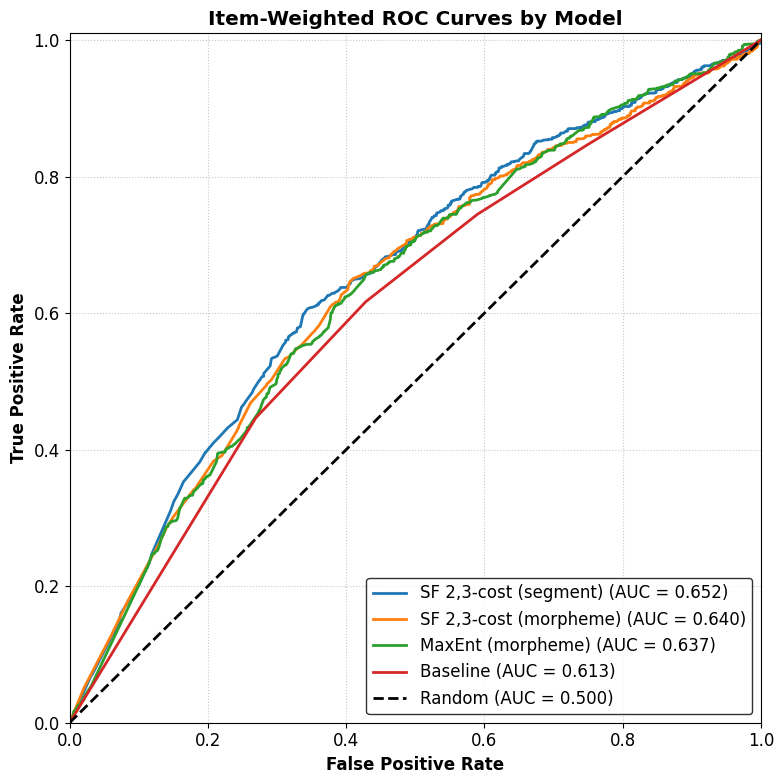

,model,roc_auc_item_weighted
0,23-sfcost-prod,0.651725
1,23-sfcost-Sublex-prod,0.639634
2,Sublex_Score,0.637275
3,nom_fit,0.613037


In [ ]:
### print the ROC AUC curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# copy to avoid mutating original df
df_w = init_df.copy()

# weight so that each item sums to 1
df_w["item_weight"] = 1.0 / df_w.groupby(item_col)[y_col].transform("size")

# compute item-weighted ROC AUC
auc_item_weighted = {
    model: roc_auc_score(
        df_w[y_col],
        df_w[model],
        sample_weight=df_w["item_weight"]
    )
    for model in model_cols
}

# Set up the plot style 
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 12}) # Good base font size for papers

# Define display names
model_display_names = {
    "nom_fit": "Baseline",
    "Sublex_Score": "MaxEnt (morpheme)",
    "23-sfcost-prod": "SF 2,3-cost (segment)",
    "23-sfcost-Sublex-prod": "SF 2,3-cost (morpheme)",
}

# Loop through each model to calculate and plot its curve
for model in model_cols:
    # Calculate weighted False Positive Rate (FPR) and True Positive Rate (TPR)
    fpr, tpr, thresholds = roc_curve(
        df_w[y_col], 
        df_w[model], 
        sample_weight=df_w["item_weight"]
    )
    
    # Get the pre-calculated AUC for the legend
    model_auc = auc_item_weighted[model]
    clean_name = model_display_names.get(model, model)
    
    # ---> Use clean_name in the label <---
    plt.plot(fpr, tpr, lw=2, label=f"{clean_name} (AUC = {model_auc:.3f})")

# Plot the diagonal baseline (Random Guessing)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random (AUC = 0.500)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Item-Weighted ROC Curves by Model', fontweight='bold')
plt.legend(loc="lower right", frameon=True, edgecolor='black')
plt.grid(True, linestyle=':', alpha=0.7)

# Adjust layout to ensure nothing is cut off
plt.tight_layout()

# Save as PDF
plt.savefig('item_weighted_roc_curves.pdf', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

auc_item_df = (
    pd.DataFrame.from_dict(auc_item_weighted, orient="index", columns=["roc_auc_item_weighted"])
      .reset_index()
      .rename(columns={"index": "model"})
      .sort_values("roc_auc_item_weighted", ascending=False)
      .reset_index(drop=True)
)

display(auc_item_df)

In [ ]:
### bootstrap the AUC deltas between models

from itertools import combinations

def bootstrap_pairwise_auc_gaps_item_weighted(
    df,
    y_col,
    item_col,
    model_cols,
    n_boot=5000,
    seed=0
):
    rng = np.random.default_rng(seed) #randomize
    items = df[item_col].unique()
    pairs = list(combinations(model_cols, 2))
    gap_samples = { (a, b): [] for (a, b) in pairs }

    for _ in range(n_boot):
        sampled_items = rng.choice(items, size=len(items), replace=True) #choose the sample of items
        boot = df[df[item_col].isin(sampled_items)].copy()

        if boot[y_col].nunique() < 2:
            continue

        # re-create item weights inside the bootstrap
        boot["item_weight"] = 1.0 / boot.groupby(item_col)[y_col].transform("size")

        # compute AUCs for all models on this bootstrap
        aucs = {
            m: roc_auc_score(
                boot[y_col], boot[m], sample_weight=boot["item_weight"]
            )
            for m in model_cols
        }

        # store gaps (B - A)
        for a, b in pairs:
            gap_samples[(a, b)].append(aucs[b] - aucs[a])

    rows = []
    for a, b in pairs:
        g = np.asarray(gap_samples[(a, b)], dtype=float)
        rows.append({
            "comparison": f"{b} > {a}",
            "mean_gap": float(g.mean()),
            "ci95_low": float(np.percentile(g, 2.5)),
            "ci95_high": float(np.percentile(g, 97.5)),
            "p(model_b_wins)": float((g > 0).mean()),
            "n_boot_used": int(len(g))
        })

    return (
        pd.DataFrame(rows)
          .sort_values("mean_gap", ascending=False)
          .reset_index(drop=True)
    )

pairwise_item_weighted = bootstrap_pairwise_auc_gaps_item_weighted(
    init_df,
    y_col=y_col,
    item_col=item_col,
    model_cols=model_cols,
    n_boot=5000,
    seed=42
)

pairwise_item_weighted
# how to read this: each comparison is Model B > Model A. Mean_gap is est. B-A. 


,comparison,mean_gap,ci95_low,ci95_high,p(model_b_wins),n_boot_used
0,Sublex_Score > 23-sfcost-Sublex-prod,-0.002231,-0.014744,0.010931,0.3630,5000
1,23-sfcost-Sublex-prod > 23-sfcost-prod,-0.012032,-0.017380,-0.006644,0.0000,5000
2,Sublex_Score > 23-sfcost-prod,-0.014263,-0.025932,-0.002382,0.0074,5000
3,nom_fit > Sublex_Score,-0.024631,-0.043256,-0.005890,0.0042,5000
4,nom_fit > 23-sfcost-Sublex-prod,-0.026862,-0.044153,-0.009375,0.0018,5000
5,nom_fit > 23-sfcost-prod,-0.038894,-0.056180,-0.021491,0.0000,5000


In [39]:
pairwise_item_weighted.to_csv('rocauc_comparisons_190626.csv')

In [40]:
init_df.to_csv('predictions_models_19062026.csv')

### Counting correlations

In [ ]:
## get the aggregation by syllabic type

import pandas as pd

model_cols =  ['nom_fit', 
			   '2-Bool', '3-Bool', '2-Bool-Sublex', '3-Bool-Sublex', 
			   '2-scost-prod', '23-scost-prod', '2-scost-Sublex-prod', '23-scost-Sublex-prod', 
			   '2-sfcost-prod', '23-sfcost-prod', 
			   '2-sfcost-Sublex-prod', '23-sfcost-Sublex-prod', 
			   'Sublex_Score', '23-sr-sfcost', '23-sr-scost']

def aggregate_by_true_type(df: pd.DataFrame, models: list[str]) -> pd.DataFrame:
    return (
        df
        .groupby("true_type", as_index=False)[models + ['accept.deletion']]
        .mean()
    )

by_type_df = aggregate_by_true_type(init_df, model_cols)

In [44]:
### counting all correlations with bootstrapped 95% CIs
from scipy import stats

def rank_models_by_correlations_with_bootstrap_ci(
    df: pd.DataFrame,
    y_col: str, #column of data to check against
    model_cols: list[str], #models to evaluate
    n_boot: int = 2000,
    ci: float = 0.95,
    seed: int = 0
) -> pd.DataFrame:
    """
    Returns a DataFrame with point estimates and bootstrap percentile CIs for:
      - Pearson r
      - Spearman rho
      - Kendall tau-b
    plus ranks for each metric.

    CIs are computed by resampling rows with replacement (nonparametric bootstrap).
    """
    rng = np.random.default_rng(seed)
    alpha = (1.0 - ci) / 2.0
    q_lo, q_hi = alpha, 1.0 - alpha

    # compute correlations between two numpy arrays
    def _corrs(xx: np.ndarray, yy: np.ndarray) -> tuple[float, float, float]:
        # guard against degenerate samples
        if len(xx) < 2 or np.all(xx == xx[0]) or np.all(yy == yy[0]):
            return (np.nan, np.nan, np.nan)
        r = stats.pearsonr(xx, yy).statistic
        rho = stats.spearmanr(xx, yy, nan_policy="omit").statistic
        tau = stats.kendalltau(xx, yy, variant="b", nan_policy="omit").statistic
        return (float(r), float(rho), float(tau))

    rows = []

    for m in model_cols:
        base = df[[y_col, m]]
        n = len(base)

        # initial correlations between exp. data and model predictions
        xx0 = base[m].to_numpy()
        yy0 = base[y_col].to_numpy()
        pearson0, spearman0, kendall0 = _corrs(xx0, yy0)

        boot_vals = np.empty((n_boot, 3), dtype=float)
        idx = np.arange(n)

        for b in range(n_boot):
            # choosing w/ replacement
            sample_idx = rng.choice(idx, size=n, replace=True)
            xx = xx0[sample_idx] 
            yy = yy0[sample_idx]
            boot_vals[b, :] = _corrs(xx, yy)

        # percentile CI, ignoring NaN 
        def _nanquantile(a: np.ndarray, q: float) -> float:
            a = a[~np.isnan(a)]
            return float(np.quantile(a, q)) if a.size else np.nan

        #get 95 CIs
        pearson_ci = (_nanquantile(boot_vals[:, 0], q_lo), _nanquantile(boot_vals[:, 0], q_hi))
        spearman_ci = (_nanquantile(boot_vals[:, 1], q_lo), _nanquantile(boot_vals[:, 1], q_hi))
        kendall_ci = (_nanquantile(boot_vals[:, 2], q_lo), _nanquantile(boot_vals[:, 2], q_hi))

        rows.append({
            "model": m,
            "n": n,
            "pearson_r": pearson0, "pearson_ci_lo": pearson_ci[0], "pearson_ci_hi": pearson_ci[1],
            "spearman_rho": spearman0, "spearman_ci_lo": spearman_ci[0], "spearman_ci_hi": spearman_ci[1],
            "kendall_tau_b": kendall0, "kendall_ci_lo": kendall_ci[0], "kendall_ci_hi": kendall_ci[1],
        })

    out = pd.DataFrame(rows)

    # ranks: 1 = best 
    out["rank_pearson"] = out["pearson_r"].rank(ascending=False, method="min")
    out["rank_spearman"] = out["spearman_rho"].rank(ascending=False, method="min")
    out["rank_kendall"] = out["kendall_tau_b"].rank(ascending=False, method="min")

    # Sorting by Pearson
    out = out.sort_values(["rank_pearson", "rank_spearman", "rank_kendall"]).reset_index(drop=True)

    return out

corr_df = rank_models_by_correlations_with_bootstrap_ci(by_type_df, 'accept.deletion', model_cols)

In [45]:
corr_df

,model,n,pearson_r,pearson_ci_lo,pearson_ci_hi,spearman_rho,spearman_ci_lo,spearman_ci_hi,kendall_tau_b,kendall_ci_lo,kendall_ci_hi,rank_pearson,rank_spearman,rank_kendall
0,Sublex_Score,46,0.892881,0.834484,0.938601,0.853635,0.745361,0.917480,0.673497,0.564350,0.777462,1.0,2.0,2.0
1,23-sr-sfcost,46,0.878698,0.824703,0.924766,0.852704,0.732122,0.908814,0.661164,0.536147,0.760446,2.0,3.0,3.0
2,23-sfcost-prod,46,0.843809,0.780305,0.922818,0.858571,0.717190,0.923009,0.683230,0.549127,0.790573,3.0,1.0,1.0
3,23-sr-scost,46,0.807231,0.728475,0.874176,0.739718,0.557662,0.846584,0.528737,0.376037,0.662363,4.0,6.0,6.0
4,23-scost-prod,46,0.781455,0.692094,0.875015,0.792361,0.633228,0.881696,0.609262,0.471133,0.725507,5.0,5.0,4.0
5,nom_fit,46,0.738077,0.640404,0.824745,0.655190,0.479914,0.757957,0.432128,0.293232,0.559630,6.0,8.0,8.0
6,23-sfcost-Sublex-prod,46,0.712910,0.598810,0.830824,0.804147,0.657235,0.881792,0.607315,0.463964,0.721886,7.0,4.0,5.0
7,2-scost-Sublex-prod,46,0.667664,0.525356,0.780395,0.620175,0.397144,0.762353,0.425371,0.253111,0.572293,8.0,9.0,9.0
8,23-scost-Sublex-prod,46,0.656066,0.541290,0.783565,0.708565,0.529328,0.817011,0.500257,0.355553,0.628834,9.0,7.0,7.0
9,2-Bool-Sublex,46,0.655934,0.494990,0.780754,0.591340,0.356918,0.741470,0.401957,0.218343,0.559360,10.0,11.0,11.0


In [46]:
corr_df.to_csv('corr_df_190626.csv')

### Exploration of phonotactic tendencies

In [47]:
#modification of the get_sum function earlier that gives you the list of violated n-grams
def get_sum2(pseudoform, bigrams=list(), trigrams=list(), feat_bigrams=list(), feat_trigrams=list()):
	c = 0
	violated_grams = []
	if len(bigrams) != 0:
		nonce_list = ['#'] + pseudoform.split('-') + ['#']
		for i in range(len(nonce_list) - 1):
			bigram = (nonce_list[i], nonce_list[i+1])
			if bigram not in bigrams:
				c += 1
				violated_grams.append(bigram)
			if len(feat_bigrams) != 0: 
				for gram in seg_to_feat(bigram):
					if gram not in feat_bigrams:
						c += 1
						violated_grams.append(gram)
	if len(trigrams) != 0:
		nonce_list = ['#', '#'] + pseudoform.split('-') +  ['#', '#']
		for i in range(len(nonce_list) - 2):
			trigram = (nonce_list[i], nonce_list[i+1], nonce_list[i+2])
			if trigram not in trigrams:
				c += 1
				violated_grams.append(trigram)
			if len(feat_trigrams) != 0:
				for gram in seg_to_feat(trigram):
					if gram not in feat_trigrams:
						c += 1
						violated_grams.append(gram)
	return c, violated_grams

In [59]:
# postor should be relatively fine as a UR with o_flt as the second o
# what is done here is evaluation of URs, since only those can provide evidence that 
# tendencies that hold for alternating items influence nonce alternation acceptance

x, y = get_sum2('p-o-s-t-o_flt-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x

1

In [60]:
#potor should be as fine
x, y = get_sum2('p-o-t-o_flt-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x

1

In [61]:
# posotr should be awful (complex coda restriction)
x, y = get_sum2('p-o-s-o_flt-t-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x #change to Y to see the list of n-grams

242

In [62]:
#posrot should be bad, due to sonority profile
x, y = get_sum2('p-o-s-r-o_flt-t', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x  #change to Y to see the list of n-grams

16

In [66]:
#pokor should be perfect
x, y = get_sum2('p-o-k-o_flt-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x

0

In [65]:
#kor should be worse: monosyllabicity effect
x, y = get_sum2('k-o_flt-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
x

4

In [67]:
#stor should be bad: monosyllabicity effect
x, y = get_sum2('s-t-o_flt-r', bigrams=ur_bigrams, trigrams=ur_trigrams, feat_bigrams=feat_ur_bigrams, feat_trigrams=feat_ur_trigrams)
y

[('t', 'o_flt', 'r')]

In [ ]:
#count how many #CV_f sequences there are
c = 0
for trigram in ur_trigrams:
	if trigram[0] == '#' and trigram[2] in ('o_flt', 'e_flt'):
		c += 1
print(c)

10


In [76]:
#contrast with other vowels
c = 0
for trigram in ur_trigrams:
	if trigram[0] == '#' and trigram[2] in ('o', 'e'):
		c += 1
print(c)

64


In [78]:
# prepare for regression
# get the relevant binary variables

def get_cc(type):
	return type[-2] not in ['о', 'е']

def get_SSP(type):
	return type in ['TR','RTR', 'TTR']

def get_mono(type):
	return type[:2] != "CV"

def get_tric(type):
	return len(type)==3

def get_vowel_type(vowel):
	return vowel == 'е'

In [79]:
#introduce them to the dataset
init_df['complex_coda'] = init_df['true_type'].apply(get_cc)
init_df['SSP'] = init_df['type'].apply(get_SSP)
init_df['mono'] = init_df['true_type'].apply(get_mono)
init_df['tric'] = init_df['type'].apply(get_tric)
init_df['vowel_type'] = init_df['vowel'].apply(get_vowel_type)

In [80]:
# aggregate by nonce item
model_cols =  ['23-sfcost-prod', 'Sublex_Score']
def aggregate_by_nonce(df: pd.DataFrame, models: list[str]) -> pd.DataFrame:
    return (
        df
        .groupby(["translit", "complex_coda", "SSP", "mono", "vowel_type", "tric"], as_index=False)[models + ['accept.deletion']]
        .mean()
    )

by_form_df = aggregate_by_nonce(init_df, model_cols)
features = ['mono', 'complex_coda', 'SSP', "tric", "vowel_type"]
by_form_df[features] = by_form_df[features].astype(int)
by_form_df.head()

,translit,complex_coda,SSP,mono,vowel_type,tric,23-sfcost-prod,Sublex_Score,accept.deletion
0,b-a-b-dj-e-v,0,1,0,1,1,0.018519,8.680656e-01,0.0
1,b-a-b-o-d,0,0,0,0,0,0.250000,1.701251e-01,0.0
2,b-a-b-o-v,0,1,0,0,0,0.100000,1.822990e-01,0.0
3,b-a-ch-e-f-sh,1,0,0,1,1,0.000143,3.459032e-11,0.0
4,b-a-ch-e-l,0,1,0,1,0,0.083333,3.047484e-01,1.0


In [81]:
# run the regression for the morpheme structure phonotactic model outputs
import statsmodels.formula.api as smf

formula = '''Q("23-sfcost-prod") ~ mono + complex_coda + vowel_type + SSP * tric'''

results = smf.ols(formula=formula, data=by_form_df).fit(cov_type='HC3')

print(results.summary())

                             OLS Regression Results                            
Dep. Variable:     Q("23-sfcost-prod")   R-squared:                       0.390
Model:                             OLS   Adj. R-squared:                  0.389
Method:                  Least Squares   F-statistic:                     254.5
Date:                 Tue, 19 May 2026   Prob (F-statistic):          9.55e-267
Time:                         19:34:40   Log-Likelihood:                 3236.5
No. Observations:                 3211   AIC:                            -6459.
Df Residuals:                     3204   BIC:                            -6416.
Df Model:                            6                                         
Covariance Type:                   HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1666      0.006    

In [82]:
# run the regression for the sublexical MaxEnt model outputs

formula = '''Q("Sublex_Score") ~ mono + vowel_type + complex_coda + SSP * tric'''

results = smf.ols(formula=formula, data=by_form_df).fit(cov_type='HC3')

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      Q("Sublex_Score")   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     417.0
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        19:34:45   Log-Likelihood:                 414.06
No. Observations:                3211   AIC:                            -814.1
Df Residuals:                    3204   BIC:                            -771.6
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.3639      0.011     31.978   